## **Compositional Kernel Search for Gaussian Processes**

Despite its importance, choosing the right covariance kernel to use with a Gaussian Process model can be a difficult task. For example, when modelling long-term historical data, one may be interested in local seasonal effects (short-term periodic parts of the signal), as well as long-term global trends.

In addition to the commonly chosen kernel functions, the space of possible kernels become very complicated when including _compositional kernels_, such as adding or multiplying two kernels together. For a brief reference on compositional kernels, see [here](https://www.cs.toronto.edu/~duvenaud/cookbook/).

The `twinlab` library comes with a feature called _Model Selection_ which automates the process of kernel selection and composition. This algorithm is a mix of two well-known algorithms: [Compositional Kernel Search](https://arxiv.org/pdf/1302.4922.pdf) and [Scalable Structure Discovery](http://proceedings.mlr.press/v84/kim18a/kim18a.pdf).

This notebook will cover:

- Compositional Kernel Search in `Emulator`


In [7]:
# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# twinlab import`
import twinlab as tl

### **Problem Formulation**

Here, we will design a function with multiple components that may be interest for modelling purposes.


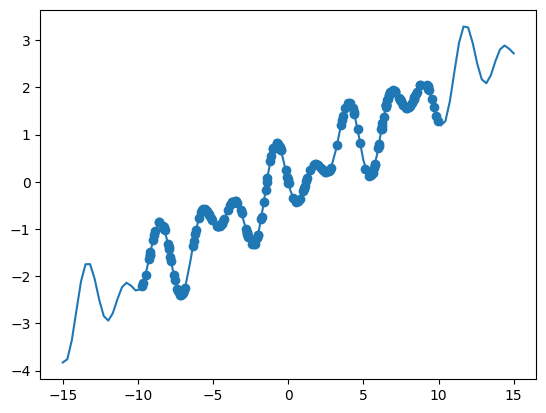

In [8]:
# The true function
def oscillator(x):
    return np.cos((x - 5) / 2) * np.sin(10 * x / 5) + x * 0.2


X = np.linspace(-15, 15, 100)[:, np.newaxis]
y = oscillator(X)  # Arrange outputs as feature columns

n_data = 200
X_data = np.random.uniform(-10, 10, size=n_data)
y_data = oscillator(X_data)

plt.plot(X, y)
plt.scatter(X_data, y_data)
plt.show()

In [9]:
# Convert to dataframe
df = pd.DataFrame({"x": X_data, "y": y_data})
df.head()

,x,y
0,9.272637,2.015075
1,9.228379,2.043587
2,-0.075361,0.108520
3,2.309457,0.239250
4,-5.517684,-0.584288


In [10]:
# Define the name of the dataset
dataset_id = "ModelSelect_Data"
dataset = tl.Dataset(dataset_id)

# Upload the dataset to the cloud
dataset.upload(df,verbose=True)

# printing info to check the datset
dataset.view(verbose=True)
dataset.summarise(verbose=True)

Dataframe is uploading.
Processing dataset
Dataset ModelSelect_Data was processed.
Dataset:
            x         y
0    9.272637  2.015075
1    9.228379  2.043587
2   -0.075361  0.108520
3    2.309457  0.239250
4   -5.517684 -0.584288
..        ...       ...
195  4.009535  1.669803
196  3.648321  1.391777
197 -4.544634 -0.928646
198 -2.072729 -1.193217
199 -9.733146 -2.217504

[200 rows x 2 columns]
Dataset summary:
                x           y
count  200.000000  200.000000
mean     0.142044    0.068709
std      5.789569    1.277831
min     -9.733146   -2.394357
25%     -4.704214   -0.936774
50%     -0.327310    0.091428
75%      6.001543    1.323131
max      9.972603    2.060080


,x,y
count,200.000000,200.000000
mean,0.142044,0.068709
std,5.789569,1.277831
min,-9.733146,-2.394357
25%,-4.704214,-0.936774
50%,-0.327310,0.091428
75%,6.001543,1.323131
max,9.972603,2.060080


### **GP without Model Selection**

For a fair comparison, we will want to run a standard GP with the ubiquitous Matern 5/2 kernel first.

To Further costumize the Emulator parameters we create an object of the Train Parameters Class and pass in the aditonal parameters as attributes


In [11]:
# Initialise emulator
emulator1 = tl.Emulator("BasicGP")

# Definind a training parameters class, sort this out to define the possible values and illustrate 

train_params = tl.TrainParams(
    train_test_ratio=0.75,
    estimator = "gaussian_process_regression",
)

# Start the training with the parameters defined

emulator1.train(dataset_id = dataset_id, 
                   inputs = ["x"],  # Using the datasets column headers define the input and output data
                   outputs =  ["y"],
                   params = train_params,
                   verbose = True
                   )

Model BasicGP has begun training.
Training complete!


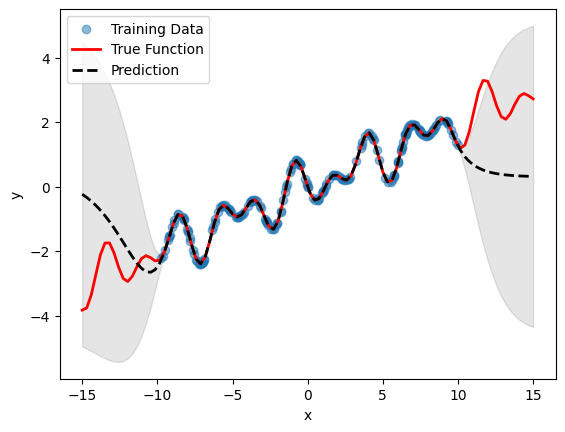

In [12]:
# Plot inference results

df_mean, df_stdev = emulator1.predict(pd.DataFrame(X, columns=["x"]))
y_mean, y_stdev = df_mean.values, df_stdev.values

plt.fill_between(
    X.flatten(),
    (y_mean - 1.96 * y_stdev).flatten(),
    (y_mean + 1.96 * y_stdev).flatten(),
    color="k",
    alpha=0.1,
)

plt.scatter(df["x"], df["y"], alpha=0.5, label="Training Data")
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X, y, c="r", linewidth=2, label="True Function")
plt.plot(X, y_mean, c="k", linewidth=2, linestyle="dashed", label="Prediction")
plt.legend()
plt.show()

### **GP with Model Selection**

Model selection in `twinlab` is exposed via the `'model_selection'=True attribute of `TrainParams` 
`Additional keyword parameters to control the model selection process can be passed to the `'ModelSelection()'` class. 

Important keywords include `'depth'`, which controls the maximum number of compositional kernels to search for, and `'beam'`, which controls the number of successful trials carried between search iterations. `'beam'=1` corresponds to greedy search, and `'beam'=None` corresponds to grid search (this is the default, but will result in exponential computational complexity). It is highly recommended to also provide a `'seed'` keyword parameter to allow reproducibility.

Note that the model achieved by this process is no more _correct_ when compared to the basic model (as they are just different ways of describing the same data), however the model with automatic compositional kernel may have better extrapolation properties.


In [13]:
# Initialise campaign
emulator2 = tl.Emulator("ModelSelectionGP")

# left a commented out thing to demo tommorow
# campaign_params = {
#     "dataset_id": dataset_id,  # This points the campaign to the uploaded dataset
#     "inputs": [
#         "x"
#     ],  # Using the datasets column headers define the input and output data
#     "outputs": ["y"],
#     "test_train_ratio": 0.75,  # Determine how much data is used for training, here 75% is used to train the model
#     "estimator": "gaussian_process_regression",  # and 25% is used to test it.
#     "model_selection": True,
#     "model_selection_kwargs": {"depth": 4, "beam": 2, "seed": 123},
# }

model_selection_params = tl.ModelSelectionParams(
        depth=4,
        beam=2,
        seed=123,
)

train_params = tl.TrainParams(
    train_test_ratio=0.75,
    estimator = "gaussian_process_regression",
    model_selection=True,
    model_selection_params= model_selection_params)

# Start a new campaign and train a surrogate model
emulator2.train(dataset_id,
               inputs=["x"],
               outputs=["y"],
               verbose=True,
               params=train_params
               )


Model ModelSelectionGP has begun training.
Training complete!


In [ ]:
# Plot inference results
df_mean, df_stdev = emulator2.train(pd.DataFrame(X, columns=["x"]))
y_mean, y_stdev = df_mean.values, df_stdev.values

plt.fill_between(
    X.flatten(),
    (y_mean - 1.96 * y_stdev).flatten(),
    (y_mean + 1.96 * y_stdev).flatten(),
    color="k",
    alpha=0.1,
)

plt.scatter(df["x"], df["y"], alpha=0.5, label="Training Data")
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X, y, c="r", linewidth=2, label="True Function")
plt.plot(X, y_mean, c="k", linewidth=2, linestyle="dashed", label="Prediction")
plt.legend()
plt.show()

In [ ]:
dataset = tl.Dataset('micol_dataset', )

In [ ]:
# Delete campaigns and dataset
emulator1.delete()
emulator2.delete()
dataset.delete()